
# Member 1 — Dataset Understanding & Data Quality Analysis

## Objectives
- Understand dataset structure
- Inspect dataset quality
- Handle missing values
- Analyze duplicates


In [1]:
import os
import pandas as pd

# Load dataset with a safe path fallback
# First tries your local project path, then tries common relative paths if the notebook is moved
dataset_paths = [
    r"C:\Users\Aryan\Desktop\NLP\NLP-Sentiment-Analysis\Data set\dataset -P676 (1).xlsx",
    "dataset -P676 (1).xlsx",
    os.path.join("Data set", "dataset -P676 (1).xlsx"),
    "/mnt/data/dataset -P676 (1).xlsx"
]

for path in dataset_paths:
    if os.path.exists(path):
        dataset_path = path
        break
else:
    raise FileNotFoundError("Dataset file not found. Please keep 'dataset -P676 (1).xlsx' in the notebook folder or Data set folder.")

# Read Excel dataset
df = pd.read_excel(dataset_path)

print("Dataset loaded from:", dataset_path)
df.head()


Dataset loaded from: C:\Users\Aryan\Desktop\NLP\NLP-Sentiment-Analysis\Data set\dataset -P676 (1).xlsx


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


## Dataset Inspection

In [2]:

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Dataset Shape: (1440, 3)

Columns:
Index(['title', 'rating', 'body'], dtype='object')

Data Types:
title     object
rating     int64
body      object
dtype: object


## Identified Important Columns

In [3]:

title_column = "title"
rating_column = "rating"
body_column = "body"

print("Title Column:", title_column)
print("Rating Column:", rating_column)
print("Body Column:", body_column)


Title Column: title
Rating Column: rating
Body Column: body


## Missing Value Analysis

In [4]:

missing_values = df.isnull().sum()
missing_values


title     0
rating    0
body      0
dtype: int64

## Handling Missing Values

In [5]:

# Remove rows with missing important review text
important_cols = [col for col in ["title", "rating", "body"] if col != "None"]

cleaned_df = df.dropna(subset=important_cols)

print("Original Shape:", df.shape)
print("After Removing Missing Values:", cleaned_df.shape)


Original Shape: (1440, 3)
After Removing Missing Values: (1440, 3)


## Duplicate Analysis

In [6]:

duplicate_rows = df.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

if "title" != "None":
    print("Duplicate Titles:", df["title"].duplicated().sum())

if "body" != "None":
    print("Duplicate Bodies:", df["body"].duplicated().sum())


Duplicate Rows: 0
Duplicate Titles: 89
Duplicate Bodies: 0


## Remove Duplicate Rows

In [7]:

df_no_duplicates = cleaned_df.drop_duplicates()

print("Shape Before Removing Duplicates:", cleaned_df.shape)
print("Shape After Removing Duplicates:", df_no_duplicates.shape)


Shape Before Removing Duplicates: (1440, 3)
Shape After Removing Duplicates: (1440, 3)


## Final Dataset Summary

In [8]:

print(df_no_duplicates.info())

df_no_duplicates.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None


,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Good phone for budget buyers. Sound quality is...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


# Aryan Part 3 - Encoding, Cleaning & Preprocessing

This section performs only Member 3 tasks: encoding checks, Unicode normalization, multilingual text cleaning, and preparation of final cleaned text columns for downstream members.

**Note:** This section uses Member 1's `df_no_duplicates` output if it is available. If the notebook is run from this section directly, it safely falls back to `cleaned_df` or `df` so that `df_member3` is always created properly.


In [9]:
# Import required libraries for text cleaning and preprocessing

# re is used for removing URLs, symbols, punctuation, and extra spaces
import re

# unicodedata is used for Unicode normalization of multilingual text
import unicodedata

# pandas is used for dataframe handling and summary report creation
import pandas as pd

# BeautifulSoup is used to remove HTML tags from review text
from bs4 import BeautifulSoup


In [10]:
# Create a separate working dataframe for Member 3
# Priority:
# 1. Use df_no_duplicates from Member 1 if it exists
# 2. Otherwise use cleaned_df if available
# 3. Otherwise use original df as a fallback
# This avoids NameError and keeps Member 1 data unchanged

if 'df_no_duplicates' in globals():
    df_member3 = df_no_duplicates.copy()
    source_used = 'df_no_duplicates'
elif 'cleaned_df' in globals():
    df_member3 = cleaned_df.copy()
    source_used = 'cleaned_df'
elif 'df' in globals():
    df_member3 = df.copy()
    source_used = 'df'
else:
    raise NameError("No dataframe found. Please run the dataset loading cell first.")

# Display shape for quick verification
print(f"Member 3 input source: {source_used}")
print(f"Member 3 input shape: {df_member3.shape}")

# Preview first few records
df_member3.head()


Member 3 input source: df_no_duplicates
Member 3 input shape: (1440, 3)


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [11]:
# Define required columns for Member 3 processing
# title  -> review title / heading
# body   -> main review text
# rating -> rating or sentiment-related value

required_columns = ['title', 'body', 'rating']

# Check whether all required columns are present in df_member3
missing_columns = [col for col in required_columns if col not in df_member3.columns]

# Raise an error if any required column is missing
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Confirm required columns are available
print('All required columns are available for Member 3:', required_columns)


All required columns are available for Member 3: ['title', 'body', 'rating']


In [12]:
# Function to detect likely broken or unreadable characters in text
# Broken characters usually happen because of encoding mismatch while reading multilingual data
# Examples: �, Ã, Â, â, ???

def has_broken_characters(text):
    # Convert missing values to an empty string for safe processing
    text = '' if pd.isna(text) else str(text)
    
    # Common broken-character patterns seen in corrupted Unicode text
    broken_patterns = ['�', 'Ã', 'Â', 'â', '€', '™', '???']
    
    # Return True if any broken pattern is found in the text
    return any(pattern in text for pattern in broken_patterns)

# Count rows with broken characters in title and body separately
broken_title_count = df_member3['title'].apply(has_broken_characters).sum()
broken_body_count = df_member3['body'].apply(has_broken_characters).sum()

# Display a compact broken-character report
print('Broken Character Report')
print('-----------------------')
print(f"Rows with broken characters in title: {broken_title_count}")
print(f"Rows with broken characters in body: {broken_body_count}")


Broken Character Report
-----------------------
Rows with broken characters in title: 0
Rows with broken characters in body: 2


In [13]:
# Function to normalize Unicode text into a consistent form
# Unicode normalization helps maintain proper representation of multilingual scripts
# such as Hindi, Telugu, Tamil, and English mixed text

def normalize_unicode(text):
    # Convert missing values to an empty string
    text = '' if pd.isna(text) else str(text)
    
    # NFKC standardizes visually similar Unicode characters into a consistent form
    normalized_text = unicodedata.normalize('NFKC', text)
    
    # Return normalized text
    return normalized_text


In [14]:
# Function to clean multilingual text while preserving Hindi, Telugu, and Tamil scripts
# This function removes noise but keeps useful multilingual review content

def clean_multilingual_text(text):
    # Normalize Unicode first to reduce encoding inconsistencies
    text = normalize_unicode(text)
    
    # Remove HTML tags if present in review text
    # Example: <br>, <p>, <div>
    text = BeautifulSoup(text, 'html.parser').get_text(' ')
    
    # Remove URLs from the text
    # Example: https://example.com or www.example.com
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # Convert English characters to lowercase
    # This does not affect Hindi, Telugu, or Tamil characters
    text = text.lower()
    
    # Remove unwanted symbols and punctuation while preserving multilingual scripts
    # Kept ranges:
    # a-z, A-Z, 0-9       -> English letters and numbers
    # ऀ-ॿ      -> Hindi / Devanagari
    # ఀ-౿      -> Telugu
    # ஀-௿      -> Tamil
    # \s                 -> spaces
    text = re.sub(
        r'[^a-zA-Z0-9\sऀ-ॿఀ-౿஀-௿]',
        ' ',
        text
    )
    
    # Replace multiple spaces, tabs, or newlines with a single space
    text = re.sub(r'\s+', ' ', text)
    
    # Remove leading and trailing spaces
    text = text.strip()
    
    # Return final cleaned text
    return text


In [15]:
# Apply the cleaning function on title and body columns

# Clean title text and store it in clean_title column
df_member3['clean_title'] = df_member3['title'].apply(clean_multilingual_text)

# Clean body text and store it in clean_body column
df_member3['clean_body'] = df_member3['body'].apply(clean_multilingual_text)

# Show original and cleaned columns for quick validation
df_member3[['title', 'clean_title', 'body', 'clean_body']].head()


,title,clean_title,body,clean_body
0,Horrible product,horrible product,Very disappointed with the overall performance...,very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,camera quality is not like 48 megapixel,Camera quality is low,camera quality is low
2,Overall,overall,"Got the mobile on the launch date,Battery must...",got the mobile on the launch date battery must...
3,A big no from me,a big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,1 it doesn t work with 5 0ghz wifi frequency 2...
4,Put your money somewhere else,put your money somewhere else,"Not worth buying....faulty software, poor disp...",not worth buying faulty software poor display ...


In [16]:
# Combine clean_title and clean_body into one final review_text column
# This final column will be used by the next members for tokenization, analysis, and modeling

df_member3['review_text'] = (df_member3['clean_title'] + ' ' + df_member3['clean_body']).str.strip()

# Replace repeated spaces again after concatenation
df_member3['review_text'] = df_member3['review_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Preview the final combined review text
df_member3[['clean_title', 'clean_body', 'review_text']].head()


,clean_title,clean_body,review_text
0,horrible product,very disappointed with the overall performance...,horrible product very disappointed with the ov...
1,camera quality is not like 48 megapixel,camera quality is low,camera quality is not like 48 megapixel camera...
2,overall,got the mobile on the launch date battery must...,overall got the mobile on the launch date batt...
3,a big no from me,1 it doesn t work with 5 0ghz wifi frequency 2...,a big no from me 1 it doesn t work with 5 0ghz...
4,put your money somewhere else,not worth buying faulty software poor display ...,put your money somewhere else not worth buying...


In [17]:
# Check whether cleaning created any empty text rows
# Empty rows may occur if title/body had only symbols, URLs, or missing text

empty_clean_title_count = (df_member3['clean_title'] == '').sum()
empty_clean_body_count = (df_member3['clean_body'] == '').sum()
empty_review_count = (df_member3['review_text'] == '').sum()

# Display empty-text report
print('Empty Text Report After Cleaning')
print('--------------------------------')
print(f"Rows with empty clean_title: {empty_clean_title_count}")
print(f"Rows with empty clean_body: {empty_clean_body_count}")
print(f"Rows with empty review_text: {empty_review_count}")


Empty Text Report After Cleaning
--------------------------------
Rows with empty clean_title: 0
Rows with empty clean_body: 0
Rows with empty review_text: 0


In [18]:
# Create a compact Member 3 summary report
# This report shows important preprocessing observations

member3_summary = pd.DataFrame({
    'Metric': [
        'Input source used',
        'Input rows',
        'Input columns',
        'Rows with broken title chars',
        'Rows with broken body chars',
        'Rows with empty clean_title',
        'Rows with empty clean_body',
        'Rows with empty review_text',
        'Final rows available'
    ],
    'Value': [
        source_used,
        len(df_member3),
        df_member3.shape[1],
        int(broken_title_count),
        int(broken_body_count),
        int(empty_clean_title_count),
        int(empty_clean_body_count),
        int(empty_review_count),
        len(df_member3)
    ]
})

# Display summary table
member3_summary


,Metric,Value
0,Input source used,df_no_duplicates
1,Input rows,1440
2,Input columns,6
3,Rows with broken title chars,0
4,Rows with broken body chars,2
5,Rows with empty clean_title,0
6,Rows with empty clean_body,0
7,Rows with empty review_text,0
8,Final rows available,1440


In [19]:
# Keep only final columns required after Member 3 preprocessing
# This keeps the Member 3 output clean and easy to share

member3_cleaned_df = df_member3[
    [
        'title',
        'body',
        'rating',
        'clean_title',
        'clean_body',
        'review_text'
    ]
].copy()

# Save cleaned dataset using UTF-8 with BOM for better Excel compatibility
member3_cleaned_df.to_csv('member3_cleaned_dataset.csv', index=False, encoding='utf-8-sig')

# Keep df_member3 as the final Member 3 dataframe
df_member3 = member3_cleaned_df.copy()

# Compatibility for the remaining notebook sections that already expect df_processed,
# title_cleaned, and body_cleaned column names.
# This does not change Member 3 final output; it only prevents later cells from breaking.
df_processed = df_member3.copy()
df_processed['title_cleaned'] = df_processed['clean_title']
df_processed['body_cleaned'] = df_processed['clean_body']

# Confirm save location and final shape
print('Saved file: member3_cleaned_dataset.csv')
print(f"Final Member 3 dataset shape: {df_member3.shape}")
print('df_processed compatibility dataframe created for next notebook sections.')


Saved file: member3_cleaned_dataset.csv
Final Member 3 dataset shape: (1440, 6)
df_processed compatibility dataframe created for next notebook sections.


## Member 3 Conclusion

In this section, encoding checking and preprocessing were performed on the multilingual review dataset. The title and body columns were checked for broken or unreadable characters, Unicode normalization was applied, and multilingual text was cleaned while preserving Hindi, Telugu, and Tamil characters.

The cleaned title and cleaned body were combined into a single `review_text` column. The final cleaned dataset was saved as `member3_cleaned_dataset.csv` and is ready for the next stages such as tokenization, stopword removal, language analysis, and modeling.


### Tokenization

Tokenization is the process of breaking a stream of text into words, phrases, symbols, or other meaningful elements called tokens. These tokens are then used as input for further processing.

In [20]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab') # Download 'punkt_tab' resource

# Apply tokenization to cleaned text
df_processed['title_tokens'] = df_processed['title_cleaned'].apply(word_tokenize)
df_processed['body_tokens'] = df_processed['body_cleaned'].apply(word_tokenize)

display(df_processed[['title_cleaned', 'title_tokens', 'body_cleaned', 'body_tokens']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aryan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aryan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,title_cleaned,title_tokens,body_cleaned,body_tokens
0,horrible product,"[horrible, product]",very disappointed with the overall performance...,"[very, disappointed, with, the, overall, perfo..."
1,camera quality is not like 48 megapixel,"[camera, quality, is, not, like, 48, megapixel]",camera quality is low,"[camera, quality, is, low]"
2,overall,[overall],got the mobile on the launch date battery must...,"[got, the, mobile, on, the, launch, date, batt..."
3,a big no from me,"[a, big, no, from, me]",1 it doesn t work with 5 0ghz wifi frequency 2...,"[1, it, doesn, t, work, with, 5, 0ghz, wifi, f..."
4,put your money somewhere else,"[put, your, money, somewhere, else]",not worth buying faulty software poor display ...,"[not, worth, buying, faulty, software, poor, d..."


### Removing Stop Words

Stop words are common words (like 'the', 'is', 'and') that often carry little meaning in text analysis and can be removed to reduce noise and improve processing efficiency. We will use NLTK's list of English stop words.

In [21]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply stop word removal to tokenized text
df_processed['title_tokens_cleaned'] = df_processed['title_tokens'].apply(remove_stopwords)
df_processed['body_tokens_cleaned'] = df_processed['body_tokens'].apply(remove_stopwords)

display(df_processed[['title_tokens', 'title_tokens_cleaned', 'body_tokens', 'body_tokens_cleaned']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aryan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,title_tokens,title_tokens_cleaned,body_tokens,body_tokens_cleaned
0,"[horrible, product]","[horrible, product]","[very, disappointed, with, the, overall, perfo...","[disappointed, overall, performance, samsung]"
1,"[camera, quality, is, not, like, 48, megapixel]","[camera, quality, like, 48, megapixel]","[camera, quality, is, low]","[camera, quality, low]"
2,[overall],[overall],"[got, the, mobile, on, the, launch, date, batt...","[got, mobile, launch, date, battery, must, app..."
3,"[a, big, no, from, me]",[big],"[1, it, doesn, t, work, with, 5, 0ghz, wifi, f...","[1, work, 5, 0ghz, wifi, frequency, 2, 4ghz, o..."
4,"[put, your, money, somewhere, else]","[put, money, somewhere, else]","[not, worth, buying, faulty, software, poor, d...","[worth, buying, faulty, software, poor, displa..."


### Lemmatization

Lemmatization is the process of grouping together the inflected forms of a word so they can be analyzed as a single item, identified by the word's lemma or dictionary form. For example, 'running', 'runs', and 'ran' would all be lemmatized to 'run'. This helps reduce the sparsity of the data and improves the efficiency and accuracy of text analysis tasks.

In [22]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to the cleaned tokens
df_processed['title_tokens_lemmatized'] = df_processed['title_tokens_cleaned'].apply(lemmatize_tokens)
df_processed['body_tokens_lemmatized'] = df_processed['body_tokens_cleaned'].apply(lemmatize_tokens)

display(df_processed[['title_tokens_cleaned', 'title_tokens_lemmatized', 'body_tokens_cleaned', 'body_tokens_lemmatized']].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Aryan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Aryan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,title_tokens_cleaned,title_tokens_lemmatized,body_tokens_cleaned,body_tokens_lemmatized
0,"[horrible, product]","[horrible, product]","[disappointed, overall, performance, samsung]","[disappointed, overall, performance, samsung]"
1,"[camera, quality, like, 48, megapixel]","[camera, quality, like, 48, megapixel]","[camera, quality, low]","[camera, quality, low]"
2,[overall],[overall],"[got, mobile, launch, date, battery, must, app...","[got, mobile, launch, date, battery, must, app..."
3,[big],[big],"[1, work, 5, 0ghz, wifi, frequency, 2, 4ghz, o...","[1, work, 5, 0ghz, wifi, frequency, 2, 4ghz, o..."
4,"[put, money, somewhere, else]","[put, money, somewhere, else]","[worth, buying, faulty, software, poor, displa...","[worth, buying, faulty, software, poor, displa..."


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized tokens back into strings for TF-IDF Vectorization
df_processed['title_text_lemmatized'] = df_processed['title_tokens_lemmatized'].apply(lambda x: ' '.join(x))
df_processed['body_text_lemmatized'] = df_processed['body_tokens_lemmatized'].apply(lambda x: ' '.join(x))

# Initialize TF-IDF Vectorizers
tfidf_vectorizer_title = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for titles
tfidf_vectorizer_body = TfidfVectorizer(max_features=10000) # Limiting to 10000 features for body

# Fit and transform the title text
tfidf_features_title = tfidf_vectorizer_title.fit_transform(df_processed['title_text_lemmatized'])

# Fit and transform the body text
tfidf_features_body = tfidf_vectorizer_body.fit_transform(df_processed['body_text_lemmatized'])

print("Shape of TF-IDF features for titles:", tfidf_features_title.shape)
print("Shape of TF-IDF features for body:", tfidf_features_body.shape)

# Display a sample of the feature names for titles
print("\nSample TF-IDF feature names (titles):")
print(tfidf_vectorizer_title.get_feature_names_out()[:20])

# Display a sample of the feature names for body
print("\nSample TF-IDF feature names (body):")
print(tfidf_vectorizer_body.get_feature_names_out()[:20])

Shape of TF-IDF features for titles: (1440, 1070)
Shape of TF-IDF features for body: (1440, 5342)

Sample TF-IDF feature names (titles):
['10' '100' '1000' '10000' '10500' '10999' '10k' '11' '11k' '12' '12499'
 '128' '128gb' '12k' '13' '13k' '15' '15000' '15k' '1st']

Sample TF-IDF feature names (body):
['000' '0000' '000mah' '03' '03rd' '04' '07th' '09th' '0f' '0ghz' '10'
 '100' '1000' '10000' '100gb' '102' '10299' '103' '1039' '10499']


In [24]:
from scipy.sparse import hstack

# Function to map ratings to sentiment labels
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

# Apply the function to create a new 'sentiment' column
df_processed['sentiment'] = df_processed['rating'].apply(get_sentiment)

# Combine TF-IDF features for title and body
X = hstack([tfidf_features_title, tfidf_features_body])

# The target variable 'sentiment' is now created
y = df_processed['sentiment']

print("Shape of combined features (X):", X.shape)
print("Shape of target variable (y):", y.shape)
print("\nSample of target variable (y):")
print(y.head())

Shape of combined features (X): (1440, 6412)
Shape of target variable (y): (1440,)

Sample of target variable (y):
0    negative
1     neutral
2    positive
3    negative
4    negative
Name: sentiment, dtype: object


In [25]:
!pip install --upgrade pip setuptools wheel

  Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Aryan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip setuptools wheel


In [26]:
!pip install langdetect


  Using cached langdetect-1.0.9.tar.gz (981 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993254 sha256=2b4de2918414496dbca5a004ed50a6635b9f7872905a8f63a6d8402de18fc697
  Stored in directory: c:\users\aryan\appdata\local\pip\cache\wheels\95\03\7d\59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect

# Create Language Detection Function

In [28]:
def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"

# Apply Language Detection

In [29]:
df_processed['language'] = df_processed['body_cleaned'].apply(
    detect_language
)

# Check Output

In [30]:
df_processed[['body_cleaned', 'language']].head(10)

,body_cleaned,language
0,very disappointed with the overall performance...,en
1,camera quality is low,en
2,got the mobile on the launch date battery must...,en
3,1 it doesn t work with 5 0ghz wifi frequency 2...,en
4,not worth buying faulty software poor display ...,en
5,i will never purchase samsung phones phone is ...,en
6,this is worst samsung mobile i have seen from ...,en
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 pm बत...,hi
8,the phone hangs a lot and is very slow i recei...,en
9,very poor quality camera found box seal damage...,en


# Convert Language Codes

In [31]:
language_map = {
    "en": "English",
    "hi": "Hindi",
    "ta": "Tamil",
    "te": "Telugu"
}

df_processed["language"] = (
    df_processed["language"]
    .map(language_map)
    .fillna("Other")
)

In [32]:
df_processed[['body_cleaned', 'language']].head(10)

,body_cleaned,language
0,very disappointed with the overall performance...,English
1,camera quality is low,English
2,got the mobile on the launch date battery must...,English
3,1 it doesn t work with 5 0ghz wifi frequency 2...,English
4,not worth buying faulty software poor display ...,English
5,i will never purchase samsung phones phone is ...,English
6,this is worst samsung mobile i have seen from ...,English
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 pm बत...,Hindi
8,the phone hangs a lot and is very slow i recei...,English
9,very poor quality camera found box seal damage...,English


# Language Distribution Analysis

In [33]:
from langdetect import detect

def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"

df_processed['language'] = df_processed['body'].apply(
    detect_language
)

In [34]:
language_percentage = (
    df_processed['language']
    .value_counts(normalize=True) * 100
)

print(language_percentage)

language
en    97.569444
hi     0.763889
id     0.416667
fr     0.277778
et     0.208333
no     0.138889
ca     0.138889
af     0.069444
it     0.069444
lv     0.069444
ml     0.069444
sw     0.069444
nl     0.069444
ro     0.069444
Name: proportion, dtype: float64


In [35]:
print(
    df_processed['language'].unique()
)

['en' 'hi' 'af' 'et' 'fr' 'it' 'lv' 'no' 'ml' 'id' 'sw' 'ca' 'nl' 'ro']


## Check language counts



In [36]:
print(df_processed['language'].value_counts())

language
en    1405
hi      11
id       6
fr       4
et       3
no       2
ca       2
af       1
it       1
lv       1
ml       1
sw       1
nl       1
ro       1
Name: count, dtype: int64


## DOMINANT LANGUAGE

In [37]:
dominant_language = (
    df_processed['language']
    .mode()[0]
)

print("\nDominant Language:")
print(dominant_language)




Dominant Language:
en


## LANGUAGE DISTRIBUTION
### CHART


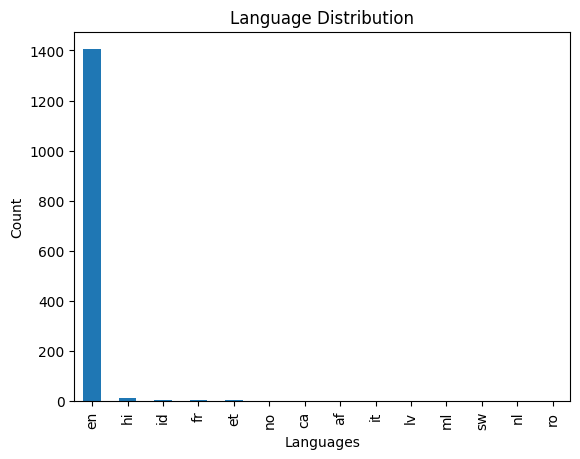

In [38]:
df_processed['language'].value_counts().plot(
    kind='bar'
)

plt.title("Language Distribution")
plt.xlabel("Languages")
plt.ylabel("Count")

plt.show()

## MIXED LANGUAGE
### DETECTION


In [39]:
def detect_mixed_language(text):

    text = str(text)

    has_english = any(
        ord(char) < 128 for char in text
    )

    has_telugu = any(
        '\u0C00' <= char <= '\u0C7F'
        for char in text
    )

    has_tamil = any(
        '\u0B80' <= char <= '\u0BFF'
        for char in text
    )

    if has_english and (
        has_telugu or has_tamil
    ):
        return "Mixed"

    return "Single"


df_processed['mixed_language'] = (
    df_processed['body']
    .apply(detect_mixed_language)
)

print("\nMixed Language Statistics:")
print(
    df_processed['mixed_language']
    .value_counts()
)




Mixed Language Statistics:
mixed_language
Single    1440
Name: count, dtype: int64


 ## TRANSLITERATION
### DETECTION

In [40]:
transliterated_words = [
    'bahut',
    'accha',
    'mast',
    'undi',
    'bagundi',
    'acha'
]


def transliteration_detection(text):

    text = str(text).lower()

    for word in transliterated_words:

        if word in text:
            return "Yes"

    return "No"


df_processed['transliteration'] = (
    df_processed['body']
    .apply(transliteration_detection)
)

print("\nTransliteration Statistics:")
print(
    df_processed['transliteration']
    .value_counts()
)


Transliteration Statistics:
transliteration
No     1432
Yes       8
Name: count, dtype: int64


##  OUTPUT

In [41]:
print(
    df_processed[
        [
            'body',
            'language',
            'mixed_language',
            'transliteration'
        ]
    ].head(10)
)


                                                body language mixed_language  \
0  Very disappointed with the overall performance...       en         Single   
1                              Camera quality is low       en         Single   
2  Got the mobile on the launch date,Battery must...       en         Single   
3  1. It doesn't work with 5.0GHz WiFi frequency....       en         Single   
4  Not worth buying....faulty software, poor disp...       en         Single   
5  I will never purchase Samsung phones. Phone is...       en         Single   
6  This is worst samsung mobile I have seen from ...       en         Single   
7  मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...       hi         Single   
8  The phone hangs a lot and is very slow. I rece...       en         Single   
9  Very poor quality camera .Found box seal damag...       en         Single   

  transliteration  
0              No  
1              No  
2              No  
3              No  
4              No  

## FINAL REPORT

In [42]:
df_processed.to_csv(
    "language_analysis_report.csv",
    index=False
)

print("\nFinal Report Saved Successfully")


Final Report Saved Successfully
